# Transición de régimen: de haz tipo CRT (Cathode Ray Tube) a sincrotrón relativista

**Planteamiento del problema**: un electrón de carga $-e$ y masa $m_e$ se acelera mediante una diferencia de potencial $V_{acc}$, entra perpendicularmente en un campo magnético uniforme $B$ y describe una trayectoria curva con aceleración centrípeta.

**Pregunta central:** ¿cómo cambian trayectoria, potencia radiada angular, ancho del lóbulo principal y contenido espectral cuando la energía cinética crece desde valores tipo CRT hasta valores relativistas de sincrotrón?

El objetivo de este estudio es determinar numéricamente el umbral de energía para el cual la distribución angular de la radiación de un electrón en movimiento circular deja de ser aproximadamente dipolar y exhibe el beaming relativista característico de la radiación de sincrotrónes. Un CRT se usa aquí como analogía de deflexión de haz: **no** es una fuente de radiación sincrotrón medible en condiciones de laboratorio comunes.

## Objetivos

A. Calcular la cinemática en campo magnético: $K=eV_{acc}$, $\gamma=1+K/(m_ec^2)$, $\beta=\sqrt{1-1/\gamma^2}$, $v=\beta c$, $\omega_0=|e|B/(\gamma m_e)$ y $R=v/\omega_0$. En unidades gaussianas, la forma equivalente es $\omega_0=|e|cB/E$.

B. Evaluar el patrón angular para $K=20\,\mathrm{keV}$, $100\,\mathrm{keV}$, $1\,\mathrm{MeV}$, $100\,\mathrm{MeV}$ y $1\,\mathrm{GeV}$ con la fórmula relativista exacta para la distribución angular instantánea.

C. Medir el FWHM del lóbulo principal y compararlo con una escala de beaming. En este trabajo se declara el ancho completo, por eso se compara con $2/\gamma$; el semiángulo característico sería $1/\gamma$.

D. Estimar armónicos y frecuencia crítica con $m_c\sim\gamma^3$ y $\omega_c\sim\gamma^3\omega_0$. Cuando se use $\omega_c=(3/2)\gamma^3\omega_0$, se indicará explícitamente la convención.

E. Comparar con un CRT: para $20\,\mathrm{kV}$, $\gamma\approx1.039$ y $\beta\approx0.27$. El CRT ilustra deflexión de haz, no régimen sincrotrón intenso.

# Marco teórico. 

La electrodinámica clásica establece que toda carga eléctrica acelerada emite radiación electromagnética. En el formalismo desarrollado por Schwinger, la radiación se obtiene a partir de los potenciales retardados y de la separación entre los campos ligados a la carga y el campo de radiación, responsable del transporte de energía hacia el infinito. La potencia emitida y su distribución angular dependen exclusivamente del estado instantáneo de movimiento de la partícula, por lo que cualquier trayectoria acelerada constituye una fuente de radiación.

Un caso de particular interés corresponde al movimiento de una carga en un campo magnético uniforme. La fuerza de Lorentz mantiene constante la rapidez del electrón y modifica únicamente la dirección de su velocidad, produciendo una trayectoria aproximadamente circular. Debido a la aceleración centrípeta, el electrón emite radiación de manera continua. En el régimen no relativista, la emisión presenta un patrón angular amplio y una frecuencia característica cercana a la frecuencia orbital, comportamiento descrito por la teoría clásica de la radiación.

El capítulo 38 de Schwinger y 14 de Jackson dedicados a la radiación sincrotrón muestran que este comportamiento cambia de forma cualitativa cuando la energía de la partícula aumenta y los efectos relativistas se vuelven importantes. La transformación relativista de los campos concentra la radiación en un cono estrecho alrededor de la dirección instantánea de movimiento, fenómeno conocido como relativistic beaming. El semiángulo característico de emisión escala aproximadamente como $1/\gamma$, de modo que el ancho angular disminuye rápidamente conforme aumenta la energía del electrón.

Simultáneamente, la estructura espectral deja de estar dominada por los primeros armónicos de la frecuencia orbital. La emisión pasa a distribuirse sobre un amplio intervalo de frecuencias, cuyo máximo se caracteriza mediante la frecuencia crítica

$\omega_c=\frac{3}{2}\gamma^3\omega_0$

donde

$\omega_0=\frac{|e|B}{\gamma m_e}$

es la frecuencia de revolución relativista. Como consecuencia, pequeños incrementos en la energía producen un aumento muy significativo de la frecuencia característica de la radiación, haciendo posible la generación de rayos X en aceleradores de electrones.

El presente proyecto estudia numéricamente la transición entre estos dos regímenes. Tomando como punto de partida un haz de electrones acelerados a energías típicas de un tubo de rayos catódicos (CRT), donde $\gamma\approx1$, y extendiendo el análisis hasta energías del orden de GeV, propias de un sincrotrón, se analizará la evolución de la trayectoria, la distribución angular de potencia, el ancho del lóbulo principal y el contenido espectral. El objetivo es identificar el umbral energético a partir del cual aparecen las propiedades distintivas de la radiación sincrotrón descritas por Schwinger.



## 1. Preparación numérica

Se usan constantes SI para la cinemática física. En las gráficas angulares se omiten factores multiplicativos comunes porque interesa la forma normalizada del patrón.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

c = 299_792_458.0  # m/s
m_e = 9.109_383_7015e-31  # kg
e_abs = 1.602_176_634e-19  # C
epsilon0 = 8.854_187_8128e-12  # F/m
mc2_eV = m_e * c**2 / e_abs

FIG_DIR = Path("Python/electrodos/Electro2/figures") if Path("Python/electrodos/Electro2/figures").exists() else Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "font.size": 10,
})

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches="tight")

def gamma_from_kinetic_energy(K_eV):
    """Factor relativista para una energía cinética electrónica en eV."""
    return 1.0 + np.asarray(K_eV, dtype=float) / mc2_eV

def beta_from_gamma(gamma):
    """Velocidad adimensional beta=v/c a partir de gamma."""
    gamma = np.asarray(gamma, dtype=float)
    return np.sqrt(1.0 - 1.0 / gamma**2)

def gamma_from_beta(beta):
    """Factor relativista a partir de beta."""
    beta = np.asarray(beta, dtype=float)
    return 1.0 / np.sqrt(1.0 - beta**2)

def orbital_frequency(B_T, gamma):
    """Frecuencia angular orbital SI para v perpendicular a B: omega0=|e|B/(gamma m_e)."""
    return e_abs * B_T / (gamma * m_e)

def orbit_radius(beta, omega0):
    """Radio de curvatura R=v/omega0."""
    return beta * c / omega0

def critical_harmonic(gamma, convention="gamma3"):
    """Armónico característico: gamma^3 o (3/2)gamma^3 según convención."""
    factor = 1.5 if convention == "three_halves" else 1.0
    return factor * np.asarray(gamma, dtype=float)**3

def critical_frequency(gamma, omega0, convention="three_halves"):
    """Frecuencia angular crítica aproximada del sincrotrón."""
    return critical_harmonic(gamma, convention=convention) * omega0

## 2. Cinemática en campo magnético

La diferencia de potencial fija la energía cinética $K=eV_{acc}$. En relatividad especial, la energía total del electrón es $E=\gamma m_ec^2=m_ec^2+K$, de modo que

$$\gamma=1+\frac{K}{m_ec^2},\qquad \beta=\sqrt{1-\frac{1}{\gamma^2}},\qquad v=\beta c.$$

Para entrada perpendicular a un campo magnético uniforme, la fuerza de Lorentz no cambia la energía: solo curva la trayectoria. En SI,

$$\omega_0=\frac{|e|B}{\gamma m_e},\qquad R=\frac{v}{\omega_0}.$$

En unidades gaussianas se escribe de forma equivalente $\omega_0=|e|cB/E$, con $E=\gamma m_ec^2$.

In [ ]:
energies_eV = np.array([20e3, 100e3, 1e6, 100e6, 1e9])
energy_labels = ["20 keV", "100 keV", "1 MeV", "100 MeV", "1 GeV"]
B_ref = 0.01  # T; campo de referencia explícito para comparar escalas

gammas_E = gamma_from_kinetic_energy(energies_eV)
betas_E = beta_from_gamma(gammas_E)
omega0_E = orbital_frequency(B_ref, gammas_E)
radii_E = orbit_radius(betas_E, omega0_E)
mc_E = critical_harmonic(gammas_E, convention="gamma3")
omega_c_E = critical_frequency(gammas_E, omega0_E, convention="three_halves")

print(f"B_ref = {B_ref:g} T")
print("K          gamma        beta        omega0 [rad/s]      R [m]        m_c~gamma^3     omega_c [rad/s]   1/gamma")
for label, g, b, w0, R, mc, wc in zip(energy_labels, gammas_E, betas_E, omega0_E, radii_E, mc_E, omega_c_E):
    print(f"{label:>7}  {g:11.4f}  {b:10.6f}  {w0:16.4e}  {R:11.4e}  {mc:14.4e}  {wc:16.4e}  {1/g:9.4e}")

g20 = gamma_from_kinetic_energy(20e3)
b20 = beta_from_gamma(g20)
print(f"\nVerificación CRT 20 keV: gamma={g20:.3f}, beta={b20:.3f}")

B_ref = 0.01 T
K          gamma        beta        omega0 [rad/s]      R [m]        m_c~gamma^3     omega_c [rad/s]   1/gamma
 20 keV       1.0391    0.271866        1.6926e+09   4.8153e-02      1.1221e+00        2.8488e+09  9.6234e-01
100 keV       1.1957    0.548221        1.4710e+09   1.1173e-01      1.7095e+00        3.7718e+09  8.3633e-01
  1 MeV       2.9570    0.941079        5.9481e+08   4.7432e-01      2.5854e+01        2.3068e+10  3.3819e-01
100 MeV     196.6951    0.999987        8.9419e+06   3.3526e+01      7.6099e+06        1.0207e+14  5.0840e-03
  1 GeV    1957.9512    1.000000        8.9830e+05   3.3373e+02      7.5059e+09        1.0114e+16  5.1074e-04

Verificación CRT 20 keV: gamma=1.039, beta=0.272


**Interpretación.** A $20\,\mathrm{keV}$ el electrón está apenas en régimen relativista leve: $\gamma\approx1.039$ y $\beta\approx0.272$. En $1\,\mathrm{MeV}$ ya aparece beaming notable porque $\gamma\approx2.96$. Entre $100\,\mathrm{MeV}$ y $1\,\mathrm{GeV}$ las escalas $m_c\sim\gamma^3$ y $\omega_c\propto\gamma^3\omega_0$ crecen de forma extrema, aunque para $B$ fijo $\omega_0$ disminuye como $1/\gamma$.

## 3. Patrón angular relativista

La parte radiativa del campo de Liénard-Wiechert produce, para una carga acelerada,

$$\frac{dP}{d\Omega}=\frac{q^2}{16\pi^2\epsilon_0 c}
\frac{\left|\mathbf n\times[(\mathbf n-\boldsymbol\beta)\times\dot{\boldsymbol\beta}]\right|^2}{(1-\mathbf n\cdot\boldsymbol\beta)^5}.$$

Aquí $q=-e$, $\mathbf n$ es el vector unitario desde la posición retardada de la carga hacia el observador, $\boldsymbol\beta=\mathbf v/c$, $\dot{\boldsymbol\beta}=\mathbf a/c$, y todas las magnitudes se evalúan en el tiempo retardado $t_{ret}$. La distancia $R=|\mathbf r-\mathbf r_q(t_{ret})|$ aparece en el campo radiativo, pero se cancela al pasar a potencia por ángulo sólido. En los gráficos normalizamos y omitimos el factor constante $q^2/(16\pi^2\epsilon_0c)$ para comparar solo la forma angular.

El numerador contiene la aceleración transversal proyectada hacia el observador; el denominador contiene el factor de aberración relativista. Ese denominador es el responsable de que la radiación se concentre hacia la dirección instantánea de movimiento.

In [ ]:
def angular_power(n, beta_vec, beta_dot_vec):
    """Patrón angular relativo dP/dOmega para una carga acelerada.

    n contiene direcciones de observación. beta_vec apunta con la velocidad
    instantánea y beta_dot_vec con la aceleración dividida por c. Se devuelve
    la forma sin constantes globales, suficiente para normalizar y comparar.
    """
    beta_vec = np.asarray(beta_vec, dtype=float)
    beta_dot_vec = np.asarray(beta_dot_vec, dtype=float)
    ndotb = np.einsum("...i,i->...", n, beta_vec)
    inner = np.cross(n - beta_vec, beta_dot_vec)
    outer = np.cross(n, inner)
    numerator = np.sum(outer**2, axis=-1)
    denominator = np.maximum(1.0 - ndotb, 1e-12)**5
    return numerator / denominator

def spherical_grid(n_theta=160, n_phi=320):
    """Malla esférica para direcciones de observación n(theta, phi).

    theta mide el ángulo respecto del eje z y phi el azimut. Cada punto de la
    malla representa una dirección posible en la que se mide la radiación.
    """
    theta = np.linspace(0.0, np.pi, n_theta)
    phi = np.linspace(0.0, 2*np.pi, n_phi)
    TH, PH = np.meshgrid(theta, phi, indexing="ij")
    n = np.stack([np.sin(TH)*np.cos(PH), np.sin(TH)*np.sin(PH), np.cos(TH)], axis=-1)
    return TH, PH, n

TH, PH, ngrid = spherical_grid()
phi = np.linspace(0.0, 2*np.pi, 4096, endpoint=False)
nplane = np.stack([np.cos(phi), np.sin(phi), np.zeros_like(phi)], axis=-1)

## 4. Superficies angulares 3D

Se toma un instante del movimiento circular: $\boldsymbol\beta$ apunta en $x$ y $\dot{\boldsymbol\beta}$ en $y$. La superficie no es una frontera física; su radio codifica intensidad normalizada.

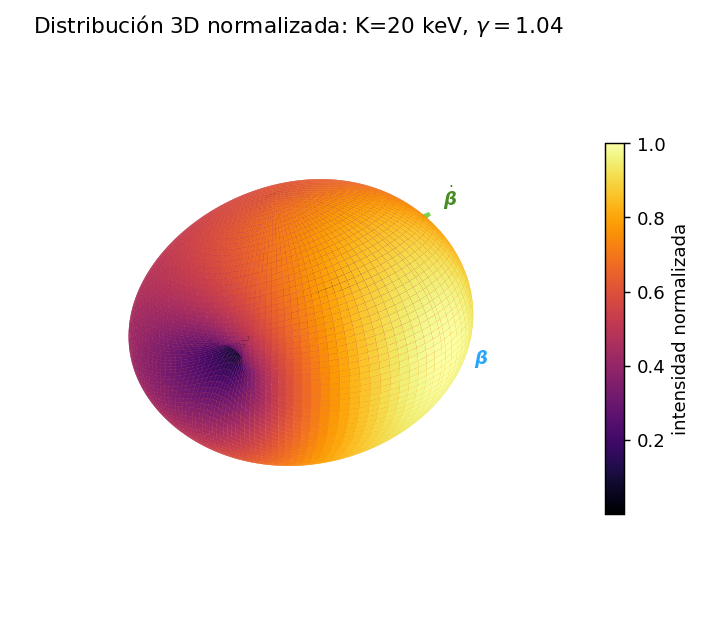

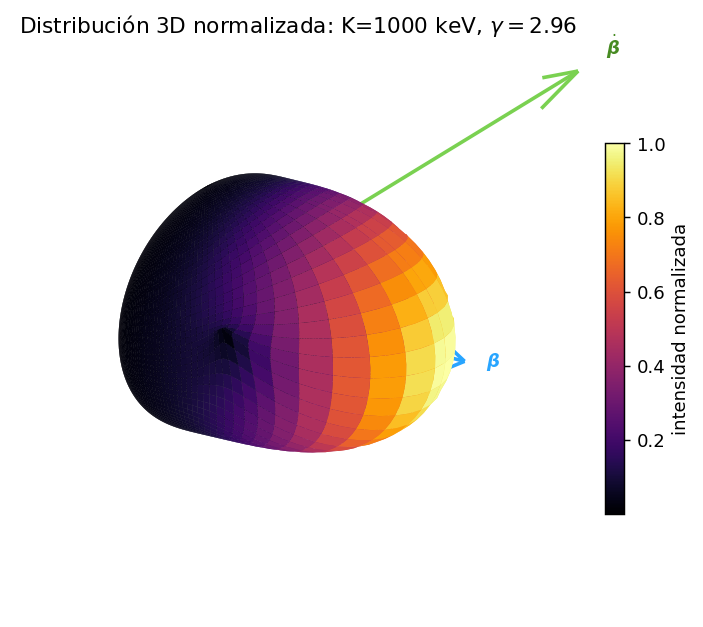

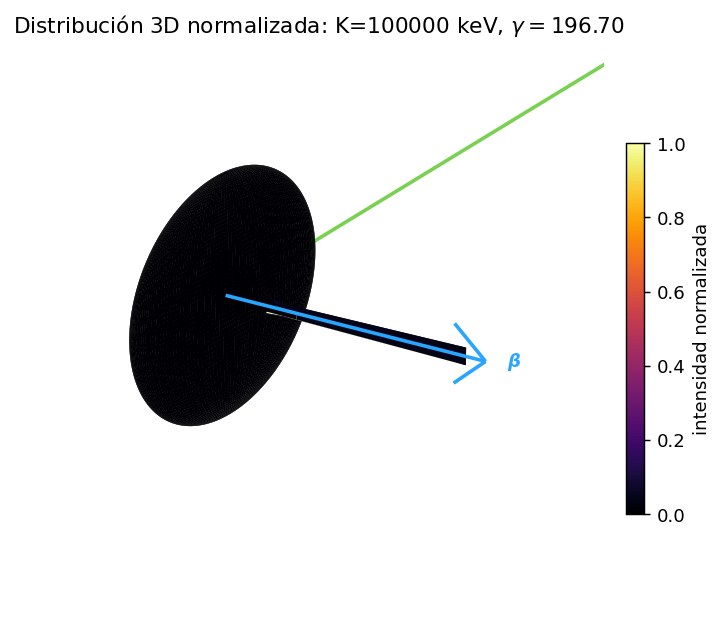

In [ ]:
def plot_angular_surface(K_eV, filename):
    gamma = gamma_from_kinetic_energy(K_eV)
    beta = float(beta_from_gamma(gamma))
    P = angular_power(ngrid, [beta, 0.0, 0.0], [0.0, 1.0, 0.0])
    Pn = P / P.max()
    radius = 0.16 + Pn**0.35
    X = radius * np.sin(TH) * np.cos(PH)
    Y = radius * np.sin(TH) * np.sin(PH)
    Z = radius * np.cos(TH)

    fig = plt.figure(figsize=(7.2, 5.7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, facecolors=cm.inferno(Pn**0.45), rstride=2, cstride=2, linewidth=0, antialiased=True, shade=False)
    ax.quiver(0, 0, 0, 1.25, 0, 0, color="#28a5ff", linewidth=2, arrow_length_ratio=0.12)
    ax.text(1.35, 0, 0, r"$\boldsymbol{\beta}$", color="#28a5ff")
    ax.quiver(0, 0, 0, 0, 1.1, 0, color="#7ad151", linewidth=2, arrow_length_ratio=0.12)
    ax.text(0, 1.2, 0, r"$\dot{\boldsymbol{\beta}}$", color="#478b22")
    ax.set_title(fr"Distribución 3D normalizada: K={K_eV/1e3:g} keV, $\gamma={gamma:.2f}$")
    ax.set_axis_off()
    ax.view_init(elev=24, azim=-58)
    mappable = cm.ScalarMappable(cmap="inferno")
    mappable.set_array(Pn)
    fig.colorbar(mappable, ax=ax, shrink=0.65, pad=0.03, label="intensidad normalizada")
    savefig(filename)
    plt.show()

for K, filename in [(20e3, "angular_3d_20keV.png"), (1e6, "angular_3d_1MeV.png"), (100e6, "angular_3d_100MeV.png")]:
    plot_angular_surface(K, filename)

**Interpretación.** La superficie de $20\,\mathrm{keV}$ todavía es ancha y comparable al patrón de aceleración transversal no relativista. A $1\,\mathrm{MeV}$ ya aparece un lóbulo hacia adelante. A $100\,\mathrm{MeV}$ el patrón se comprime tanto que la representación 3D necesita normalización logarítmica o cortes para verse con claridad.

## 5. Mapas angulares y cortes polares

Los mapas muestran la esfera de observación completa. Los cortes polares en el plano orbital permiten medir directamente el estrechamiento del lóbulo principal.

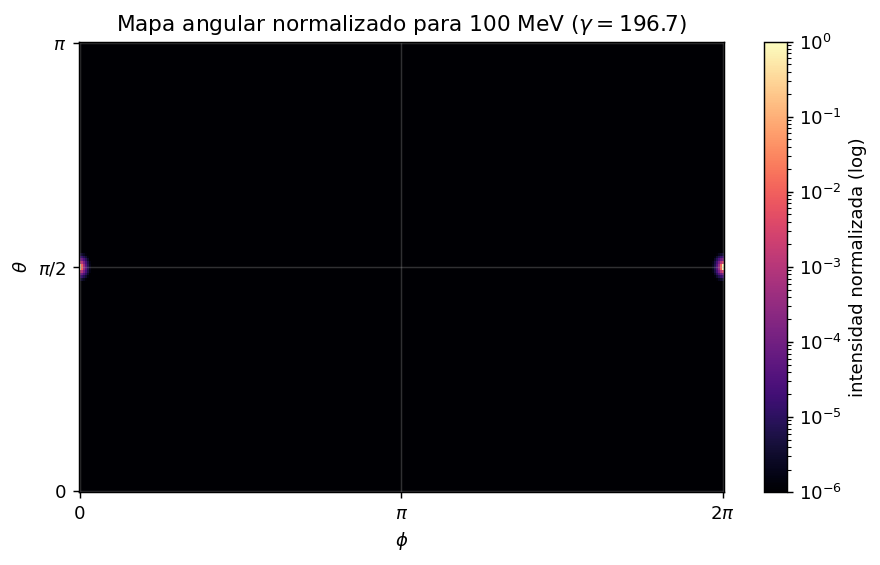

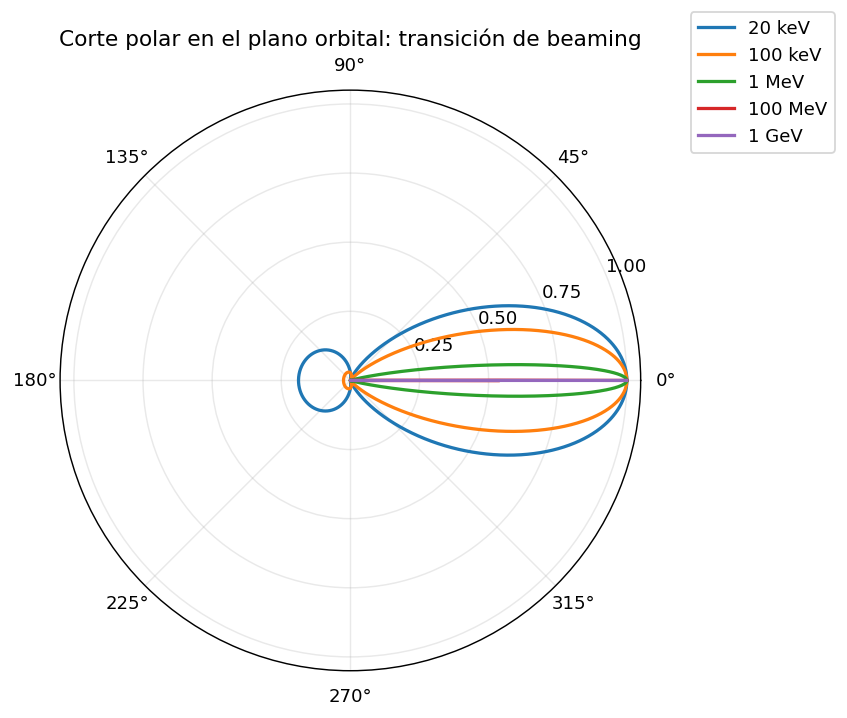

In [ ]:
K_heat = 100e6
beta_heat = float(beta_from_gamma(gamma_from_kinetic_energy(K_heat)))
P_heat = angular_power(ngrid, [beta_heat, 0.0, 0.0], [0.0, 1.0, 0.0])
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.pcolormesh(PH, TH, P_heat/P_heat.max(), shading="auto", cmap="magma", norm=LogNorm(vmin=1e-6, vmax=1.0))
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\theta$")
ax.set_title(fr"Mapa angular normalizado para 100 MeV ($\gamma={gamma_from_kinetic_energy(K_heat):.1f}$)")
ax.set_yticks([0, np.pi/2, np.pi]); ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels(["0", r"$\pi$", r"$2\pi$"])
fig.colorbar(im, ax=ax, label="intensidad normalizada (log)")
savefig("angular_heatmap_100MeV.png")
plt.show()

fig = plt.figure(figsize=(7.0, 5.8))
ax = fig.add_subplot(111, projection="polar")
for label, beta in zip(energy_labels, betas_E):
    P = angular_power(nplane, [beta, 0.0, 0.0], [0.0, 1.0, 0.0])
    ax.plot(phi, P/P.max(), lw=1.8, label=label)
ax.set_theta_zero_location("E")
ax.set_title("Corte polar en el plano orbital: transición de beaming")
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
savefig("polar_beaming_energy_comparison.png")
plt.show()

**Interpretación.** El mapa de $100\,\mathrm{MeV}$ muestra que casi toda la intensidad se concentra cerca de la dirección de movimiento. En el corte polar, $20\,\mathrm{keV}$ y $100\,\mathrm{keV}$ siguen siendo lóbulos anchos; $1\,\mathrm{MeV}$ ya marca la transición visual; $100\,\mathrm{MeV}$ y $1\,\mathrm{GeV}$ se vuelven haces extremadamente angostos.

## 6. FWHM del lóbulo principal

Se mide el ancho completo a media altura del lóbulo hacia adelante. Por convención de este notebook, el FWHM se compara con $2/\gamma$, porque $1/\gamma$ representa el semiángulo característico de beaming.

K          gamma        beta        FWHM [rad]    FWHM [deg]    2/gamma [rad]  FWHM/(2/gamma)
 20 keV       1.0391    0.271866   1.0796e+00   6.1856e+01     1.9247e+00          0.5609
100 keV       1.1957    0.548221   7.2657e-01   4.1630e+01     1.6727e+00          0.4344
  1 MeV       2.9570    0.941079   2.2261e-01   1.2754e+01     6.7637e-01          0.3291
100 MeV     196.6951    0.999987   3.2294e-03   1.8503e-01     1.0168e-02          0.3176
  1 GeV    1957.9512    1.000000   3.2442e-04   1.8588e-02     1.0215e-03          0.3176


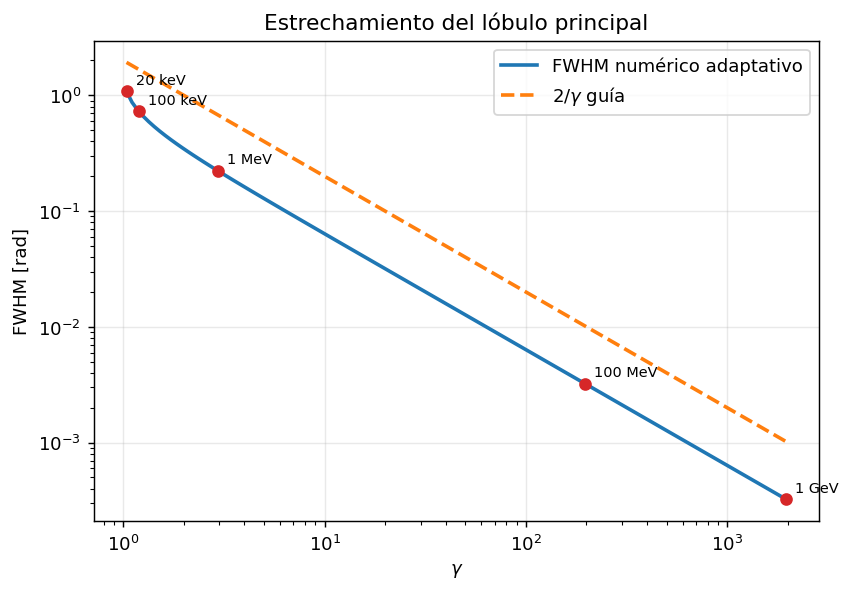

In [ ]:
def orbital_plane_power(angle, beta):
    angle = np.asarray(angle)
    n = np.stack([np.cos(angle), np.sin(angle), np.zeros_like(angle)], axis=-1)
    return angular_power(n, [beta, 0.0, 0.0], [0.0, 1.0, 0.0])

def maximize_local(func, center, half_window, iterations=70):
    lo, hi = center - half_window, center + half_window
    for _ in range(iterations):
        m1 = lo + (hi - lo) / 3
        m2 = hi - (hi - lo) / 3
        if func(m1) < func(m2):
            lo = m1
        else:
            hi = m2
    return 0.5 * (lo + hi)

def half_max_crossing(func_norm, peak_angle, direction, initial_step):
    lo = peak_angle
    hi = peak_angle + direction * initial_step
    while func_norm(hi) > 0.5:
        lo = hi
        hi = peak_angle + 2 * (hi - peak_angle)
        if abs(hi - peak_angle) >= np.pi:
            return np.nan
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if func_norm(mid) > 0.5:
            lo = mid
        else:
            hi = mid
    return hi

def fwhm_width(beta):
    gamma = gamma_from_beta(beta)
    coarse_angles = np.linspace(-np.pi, np.pi, 4097)
    coarse_power = orbital_plane_power(coarse_angles, beta)
    coarse_peak = coarse_angles[int(np.argmax(coarse_power))]
    refine_window = max(8/gamma, 4*np.pi/(len(coarse_angles)-1))
    peak_angle = maximize_local(lambda a: float(orbital_plane_power(a, beta)), coarse_peak, refine_window)
    peak_power = float(orbital_plane_power(peak_angle, beta))
    func_norm = lambda a: float(orbital_plane_power(a, beta)) / peak_power
    step = min(0.05, max(1e-7, 0.02/gamma))
    left = half_max_crossing(func_norm, peak_angle, -1, step)
    right = half_max_crossing(func_norm, peak_angle, 1, step)
    return right - left

fwhm_E = np.array([fwhm_width(beta) for beta in betas_E])
print("K          gamma        beta        FWHM [rad]    FWHM [deg]    2/gamma [rad]  FWHM/(2/gamma)")
for label, g, b, w in zip(energy_labels, gammas_E, betas_E, fwhm_E):
    print(f"{label:>7}  {g:11.4f}  {b:10.6f}  {w:11.4e}  {np.degrees(w):11.4e}  {2/g:13.4e}  {w/(2/g):14.4f}")

gamma_sweep = np.logspace(np.log10(gammas_E[0]), np.log10(gammas_E[-1]), 120)
beta_sweep = beta_from_gamma(gamma_sweep)
width_sweep = np.array([fwhm_width(beta) for beta in beta_sweep])

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.loglog(gamma_sweep, width_sweep, lw=2, label="FWHM numérico adaptativo")
ax.loglog(gamma_sweep, 2/gamma_sweep, "--", lw=2, label=r"$2/\gamma$ guía")
ax.scatter(gammas_E, fwhm_E, color="tab:red", zorder=3)
for label, g, w in zip(energy_labels, gammas_E, fwhm_E):
    ax.annotate(label, (g, w), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel("FWHM [rad]")
ax.set_title("Estrechamiento del lóbulo principal")
ax.legend()
savefig("fwhm_vs_gamma.png")
plt.show()

**Criterio de transición.** Con la convención de ancho completo, la escala relevante es $\mathrm{FWHM}\sim2/\gamma$. La radiación empieza a verse claramente no dipolar cuando $\gamma$ deja de ser cercano a 1; en esta lista, $1\,\mathrm{MeV}$ ($\gamma\approx2.96$) ya estrecha el lóbulo de forma evidente. Un criterio práctico para declarar régimen sincrotrón angular es $\gamma\gtrsim3$; para beaming muy estrecho y armónicos dominantes, $\gamma\gg1$, como $100\,\mathrm{MeV}$ o $1\,\mathrm{GeV}$.

## 7. Movimiento circular y frecuencia crítica

La fuerza magnética mantiene un movimiento circular uniforme en rapidez. La frecuencia orbital disminuye con $\gamma$, pero el pulso observado se estrecha por beaming; por eso el contenido espectral se extiende hacia armónicos altos. Usaremos $m_c\sim\gamma^3$ como escala de armónico y $\omega_c=(3/2)\gamma^3\omega_0$ como convención para la frecuencia crítica angular.

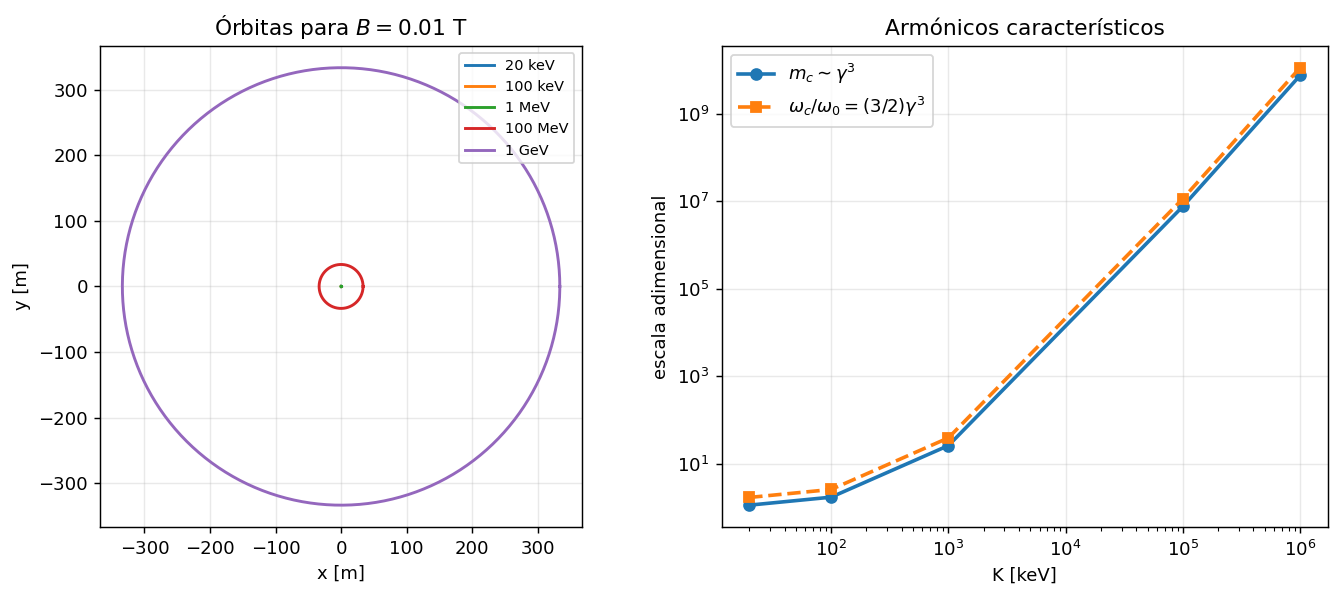

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10.8, 4.7))
t_orbit = np.linspace(0.0, 2*np.pi, 500)
for label, R in zip(energy_labels, radii_E):
    axs[0].plot(R*np.cos(t_orbit), R*np.sin(t_orbit), lw=1.6, label=label)
axs[0].set_aspect("equal")
axs[0].set_xlabel("x [m]")
axs[0].set_ylabel("y [m]")
axs[0].set_title(fr"Órbitas para $B={B_ref:g}$ T")
axs[0].legend(fontsize=8)

axs[1].loglog(energies_eV/1e3, mc_E, "o-", lw=2, label=r"$m_c\sim\gamma^3$")
axs[1].loglog(energies_eV/1e3, omega_c_E/omega0_E, "s--", lw=2, label=r"$\omega_c/\omega_0=(3/2)\gamma^3$")
axs[1].set_xlabel("K [keV]")
axs[1].set_ylabel("escala adimensional")
axs[1].set_title("Armónicos característicos")
axs[1].legend()
fig.tight_layout()
savefig("circular_motion_frequency_scales.png")
plt.show()

**Interpretación.** Para $B$ fijo, el radio aumenta fuertemente con la energía porque $R=\beta c/\omega_0\propto\gamma\beta$. La escala espectral, en cambio, crece como $\gamma^3$ medida en armónicos de la frecuencia orbital. Esa es la razón física de la transición: la emisión se concentra en pulsos angostos y esos pulsos requieren muchos armónicos para reconstruirse.

## 8. Tiempo retardado

El observador no recibe información de la posición instantánea de la carga, sino de la posición retardada. La relación geométrica es

$$t_{obs}=t_{ret}+\frac{R(t_{ret})}{c},\qquad R(t_{ret})=|\mathbf r_{obs}-\mathbf r_q(t_{ret})|.$$

En la celda siguiente se resuelve esta ecuación por bisección en unidades normalizadas con $c=1$.

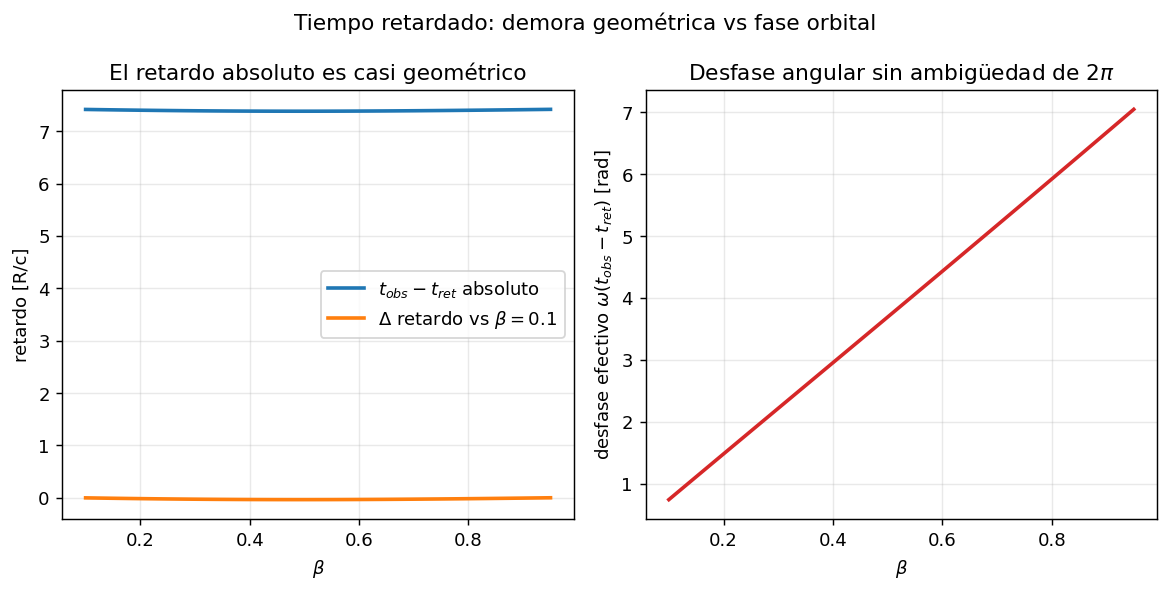

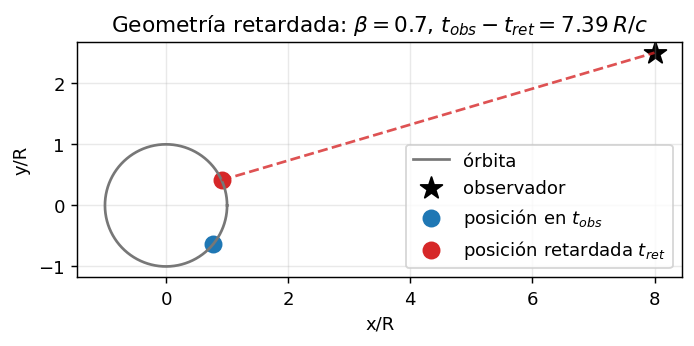

In [ ]:
def rq_circular(t, beta=0.7, R=1.0):
    """Posición de una carga en órbita circular normalizada con c=1."""
    omega = beta / R
    return np.array([R*np.cos(omega*t), R*np.sin(omega*t), 0.0])

def retarded_time_bisect(t_obs, r_obs, beta=0.7, R=1.0, tol=1e-11, max_iter=100):
    """Resuelve t_obs = t_ret + |r_obs-rq(t_ret)| por bisección.

    El retardo absoluto está dominado por la distancia geométrica, mientras que
    el desfase orbital omega*(t_obs-t_ret) crece con la velocidad angular.
    """
    def f(t_ret):
        distance = np.linalg.norm(r_obs - rq_circular(t_ret, beta, R))
        return t_ret + distance - t_obs

    hi = t_obs
    lo = t_obs - np.linalg.norm(r_obs) - R - 10*R/max(beta, 1e-3)
    while f(lo) > 0:
        lo -= 2*abs(lo-hi) + 1
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        if f(mid) <= 0:
            lo = mid
        else:
            hi = mid
        if abs(hi-lo) < tol:
            break
    return 0.5*(lo+hi)

obs = np.array([8.0, 2.5, 0.0])
t_obs = 8.0
ret_data = []
for beta in np.linspace(0.1, 0.95, 80):
    t_ret = retarded_time_bisect(t_obs, obs, beta)
    delay = t_obs - t_ret
    phase_lag = beta * delay  # omega=beta/R y R=1
    ret_data.append((beta, gamma_from_beta(beta), delay, phase_lag))
ret_data = np.array(ret_data)

fig, axs = plt.subplots(1, 2, figsize=(9.1, 4.6))
axs[0].plot(ret_data[:,0], ret_data[:,2], lw=2, label=r"$t_{obs}-t_{ret}$ absoluto")
axs[0].plot(ret_data[:,0], ret_data[:,2] - ret_data[0,2], lw=2, label=r"$\Delta$ retardo vs $\beta=0.1$")
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel("retardo [R/c]")
axs[0].set_title("El retardo absoluto es casi geométrico")
axs[0].legend(loc="best")
axs[1].plot(ret_data[:,0], ret_data[:,3], lw=2, color="tab:red")
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"desfase efectivo $\omega(t_{obs}-t_{ret})$ [rad]")
axs[1].set_title(r"Desfase angular sin ambigüedad de $2\pi$")
fig.suptitle("Tiempo retardado: demora geométrica vs fase orbital")
fig.tight_layout()
savefig("retarded_time_vs_beta.png")
plt.show()

beta_demo = 0.7
t_ret = retarded_time_bisect(t_obs, obs, beta_demo)
now = rq_circular(t_obs, beta_demo)
old = rq_circular(t_ret, beta_demo)
t_path = np.linspace(0.0, 2*np.pi, 500)
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(np.cos(t_path), np.sin(t_path), color="#777", lw=1.5, label="órbita")
ax.scatter([obs[0]], [obs[1]], marker="*", s=160, color="black", label="observador")
ax.scatter([now[0]], [now[1]], s=80, color="tab:blue", label=r"posición en $t_{obs}$")
ax.scatter([old[0]], [old[1]], s=80, color="tab:red", label=r"posición retardada $t_{ret}$")
ax.plot([old[0], obs[0]], [old[1], obs[1]], "--", color="tab:red", alpha=0.8)
ax.set_aspect("equal"); ax.set_xlabel("x/R"); ax.set_ylabel("y/R")
ax.set_title(fr"Geometría retardada: $\beta={beta_demo}$, $t_{{obs}}-t_{{ret}}={t_obs-t_ret:.2f}\,R/c$")
ax.legend(loc="best")
savefig("retarded_position_geometry.png")
plt.show()

**Interpretación.** La demora absoluta cambia poco porque el observador está lejos comparado con el radio orbital. Lo que sí cambia de forma dinámica es el desfase: a mayor velocidad angular, una misma demora geométrica corresponde a una fase orbital mayor. Ese desfase es parte de la razón por la que la radiación relativista observada se organiza como pulsos estrechos.

## 9. FFT fenomenológica: pulsos y armónicos

Esta sección **no** calcula el espectro completo de sincrotrón a partir de las funciones de Bessel. Es un proxy fenomenológico: se usa una señal periódica proporcional a $(1-\boldsymbol\beta\cdot\mathbf n)^{-3}$ para representar el estrechamiento temporal cuando el haz apunta hacia el observador. El objetivo es ver por qué los pulsos estrechos implican armónicos altos.

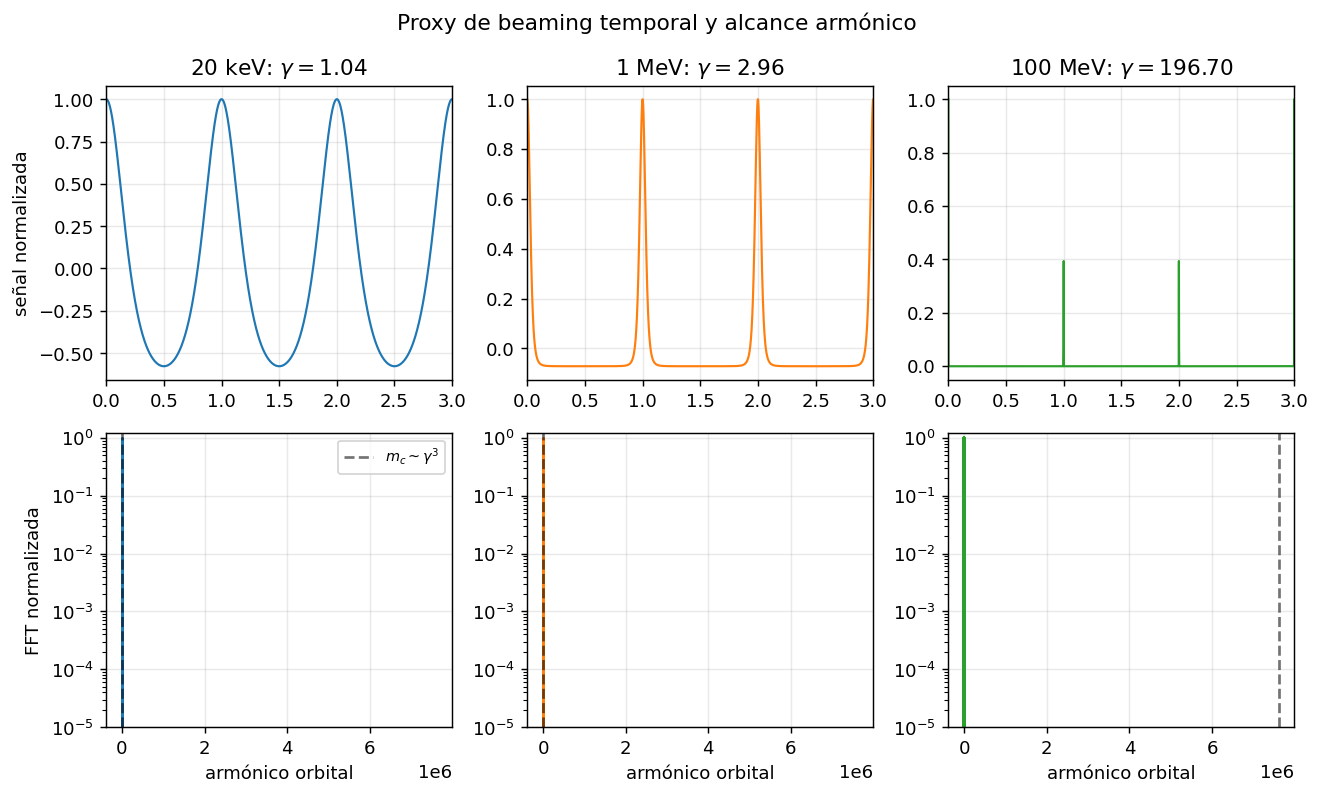

In [ ]:
N = 8192
periods = 12
tsig = np.linspace(0.0, periods*2*np.pi, N, endpoint=False)

def observed_signal(beta):
    ndotb = beta * np.cos(tsig)
    raw = (1.0 - beta**2) / np.maximum(1.0 - ndotb, 1e-10)**3
    return raw - raw.mean()

fft_cases = [(20e3, "20 keV"), (1e6, "1 MeV"), (100e6, "100 MeV")]
fig, axs = plt.subplots(2, len(fft_cases), figsize=(10.2, 6.2), sharex="row")
for col, (K_eV, label) in enumerate(fft_cases):
    gamma = float(gamma_from_kinetic_energy(K_eV))
    beta = float(beta_from_gamma(gamma))
    sig = observed_signal(beta)
    axs[0, col].plot(tsig/(2*np.pi), sig/np.max(np.abs(sig)), lw=1.2, color=f"C{col}")
    freq = np.fft.rfftfreq(N, d=(tsig[1]-tsig[0])/(2*np.pi))
    amp = np.abs(np.fft.rfft(sig))
    amp /= amp.max()
    mc = critical_harmonic(gamma, convention="gamma3")
    max_harmonic = min(max(40, 2.5*mc), 5000)
    mask = (freq > 0) & (freq < max_harmonic)
    axs[1, col].semilogy(freq[mask], amp[mask], lw=1.4, color=f"C{col}")
    axs[1, col].axvline(mc, ls="--", color="black", alpha=0.55, label=r"$m_c\sim\gamma^3$")
    axs[0, col].set_title(fr"{label}: $\gamma={gamma:.2f}$")
    axs[0, col].set_xlim(0, 3)
    axs[1, col].set_ylim(1e-5, 1.2)
    axs[1, col].set_xlabel("armónico orbital")
    if col == 0:
        axs[1, col].legend(fontsize=8)
axs[0,0].set_ylabel("señal normalizada")
axs[1,0].set_ylabel("FFT normalizada")
fig.suptitle("Proxy de beaming temporal y alcance armónico")
fig.tight_layout()
savefig("fft_harmonics_beaming.png")
plt.show()

**Interpretación.** Al aumentar $\gamma$, la señal temporal se comprime cerca del instante en que la velocidad apunta al observador. Una señal más angosta en tiempo necesita más armónicos para reconstruirse. Por eso $m_c\sim\gamma^3$ funciona como una escala de transición espectral: no es que aparezca un único armónico crítico, sino que el contenido significativo se extiende hacia órdenes mucho mayores. Esta FFT es solo una visualización fenomenológica del beaming temporal; el espectro sincrotrón completo requiere el tratamiento con funciones de Bessel y no se reproduce con este proxy.

## 10. Comparación CRT vs sincrotrón

Un CRT acelera electrones con decenas de kilovoltios y los desvía con campos eléctricos o magnéticos. Esa geometría es útil para visualizar una partícula cargada curvada por Lorentz, pero no para producir radiación sincrotrón intensa. La imagen en la pantalla no es radiación emitida por el electrón: es el punto donde el haz golpea el fósforo después de ser deflectado. Por eso el modelo de visualización de esta sección es un modelo de pantalla con deflexión de haz, no un cálculo de emisión sincrotrón. Para movimiento circular en un campo magnético fijo, la potencia radiada escala como $P\propto\gamma^2\beta^2B^2$ salvo constantes del sistema de unidades; no como $\gamma^4\beta^4$, que correspondería a otro supuesto cinemático de aceleración/radio fijo. Para un tramo magnético corto, una estimación de la deflexión en pantalla es

$$y(B)\approx\frac{|e|B}{\gamma m_e v}
\left(L_bL_d+\frac{L_b^2}{2}\right),$$

donde $L_b$ es la longitud del tramo con campo y $L_d$ la deriva hasta la pantalla. Esta fórmula describe desviación del haz, no emisión sincrotrón medible.

K          gamma        beta        P(B fijo)/P_20keV    omega_c/omega_c20
 20 keV       1.0391    0.271866         1.0000e+00         1.0000e+00
100 keV       1.1957    0.548221         5.3839e+00         1.3240e+00
  1 MeV       2.9570    0.941079         9.7025e+01         8.0973e+00
100 MeV     196.6951    0.999987         4.8475e+05         3.5829e+04
  1 GeV    1957.9512    1.000000         4.8034e+07         3.5502e+06


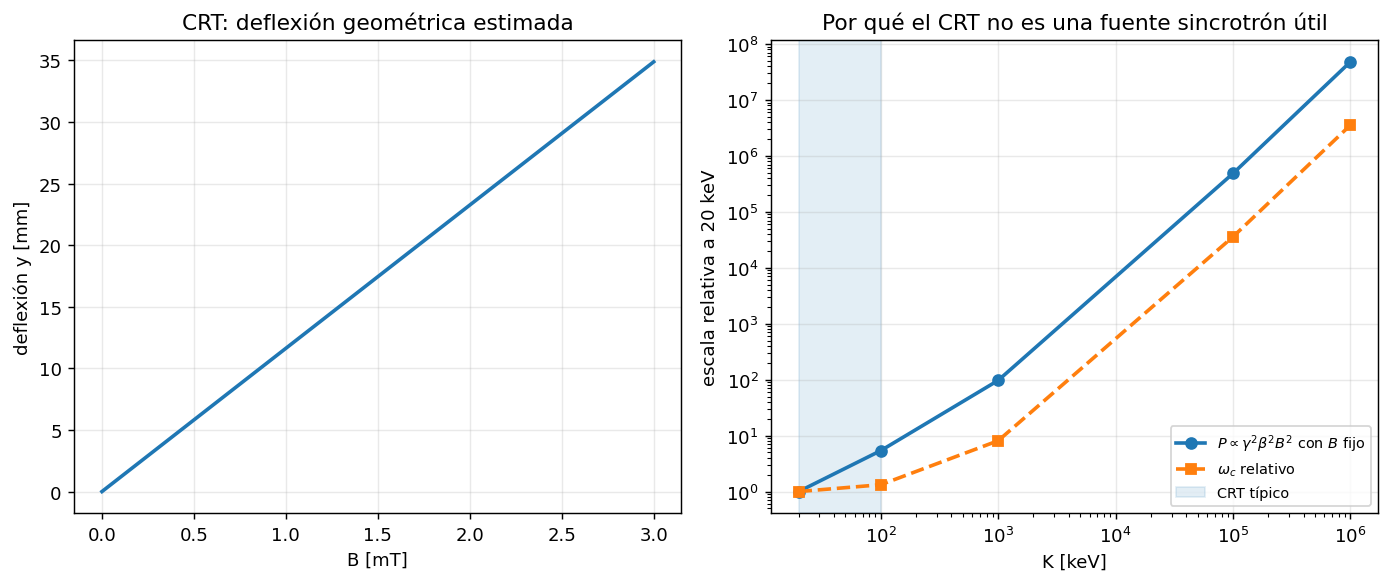

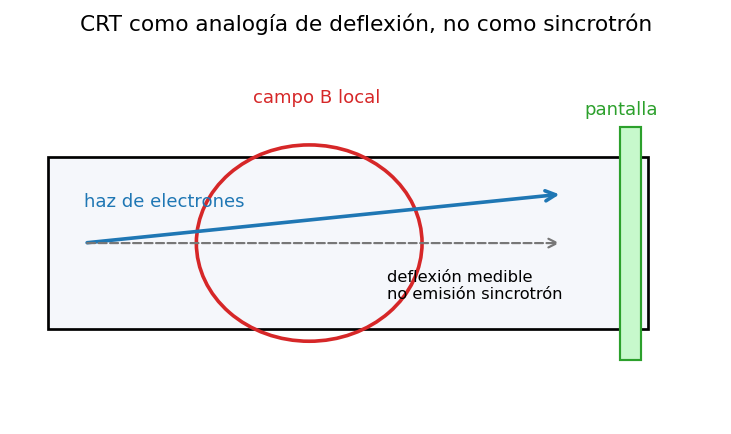

In [ ]:
def crt_deflection(B_T, K_eV=20e3, L_b=0.04, L_d=0.12):
    gamma = gamma_from_kinetic_energy(K_eV)
    beta = beta_from_gamma(gamma)
    v = beta * c
    return e_abs * B_T / (gamma * m_e * v) * (L_b*L_d + 0.5*L_b**2)

B_values = np.linspace(0, 3e-3, 120)
y_values = crt_deflection(B_values)
fixed_B_power_scale = gammas_E**2 * betas_E**2
fixed_B_power_scale /= fixed_B_power_scale[0]
print("K          gamma        beta        P(B fijo)/P_20keV    omega_c/omega_c20")
for label, g, b, p_rel, wc_rel in zip(energy_labels, gammas_E, betas_E, fixed_B_power_scale, omega_c_E/omega_c_E[0]):
    print(f"{label:>7}  {g:11.4f}  {b:10.6f}  {p_rel:17.4e}  {wc_rel:17.4e}")


fig, axs = plt.subplots(1, 2, figsize=(10.8, 4.6))
axs[0].plot(B_values*1e3, y_values*1e3, lw=2)
axs[0].set_xlabel("B [mT]")
axs[0].set_ylabel("deflexión y [mm]")
axs[0].set_title("CRT: deflexión geométrica estimada")
axs[1].loglog(energies_eV/1e3, fixed_B_power_scale, "o-", lw=2, label=r"$P\propto\gamma^2\beta^2B^2$ con $B$ fijo")
axs[1].loglog(energies_eV/1e3, omega_c_E/omega_c_E[0], "s--", lw=2, label=r"$\omega_c$ relativo")
axs[1].axvspan(20, 100, color="tab:blue", alpha=0.12, label="CRT típico")
axs[1].set_xlabel("K [keV]")
axs[1].set_ylabel("escala relativa a 20 keV")
axs[1].set_title("Por qué el CRT no es una fuente sincrotrón útil")
axs[1].legend(fontsize=8)
fig.tight_layout()
savefig("crt_vs_synchrotron_gamma.png")
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 3.8))
tube = Rectangle((0.05, 0.35), 0.85, 0.28, linewidth=1.5, edgecolor="black", facecolor="#f5f7fb")
screen = Rectangle((0.86, 0.30), 0.03, 0.38, linewidth=1.2, edgecolor="tab:green", facecolor="#c7f9cc")
coil = Circle((0.42, 0.49), 0.16, linewidth=2.0, edgecolor="tab:red", facecolor="none")
ax.add_patch(tube); ax.add_patch(screen); ax.add_patch(coil)
ax.add_patch(FancyArrowPatch((0.10, 0.49), (0.78, 0.57), arrowstyle="->", mutation_scale=14, lw=2, color="tab:blue"))
ax.add_patch(FancyArrowPatch((0.10, 0.49), (0.78, 0.49), arrowstyle="->", mutation_scale=12, lw=1.2, linestyle="--", color="#777"))
ax.text(0.10, 0.55, "haz de electrones", color="tab:blue")
ax.text(0.34, 0.72, "campo B local", color="tab:red")
ax.text(0.81, 0.70, "pantalla", color="tab:green")
ax.text(0.53, 0.40, "deflexión medible\nno emisión sincrotrón", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0.2, 0.82); ax.set_axis_off()
ax.set_title("CRT como analogía de deflexión, no como sincrotrón")
savefig("crt_schematic.png")
plt.show()

### Evolución temporal observada en una pantalla CRT

Para representar lo que se vería en una pantalla, se modela el impacto del haz sobre el fósforo. El electrón se acelera con $V_{acc}$, atraviesa una región magnética local de longitud $L_b$ y luego deriva una distancia $L_d$ hasta la pantalla. En aproximación de ángulo pequeño se usa la misma sensibilidad geométrica para ambos ejes transversales:

$$\Delta r_\perp(B)\approx\frac{|e|B}{\gamma m_ev}\left(L_bL_d+\frac{L_b^2}{2}\right).$$

El barrido horizontal se representa con una señal tipo diente de sierra y la deflexión vertical con una señal sinusoidal. La persistencia del fósforo se aproxima acumulando las posiciones recientes con decaimiento exponencial. Esta visualización describe el movimiento del punto luminoso y su traza; no describe radiación sincrotrón.

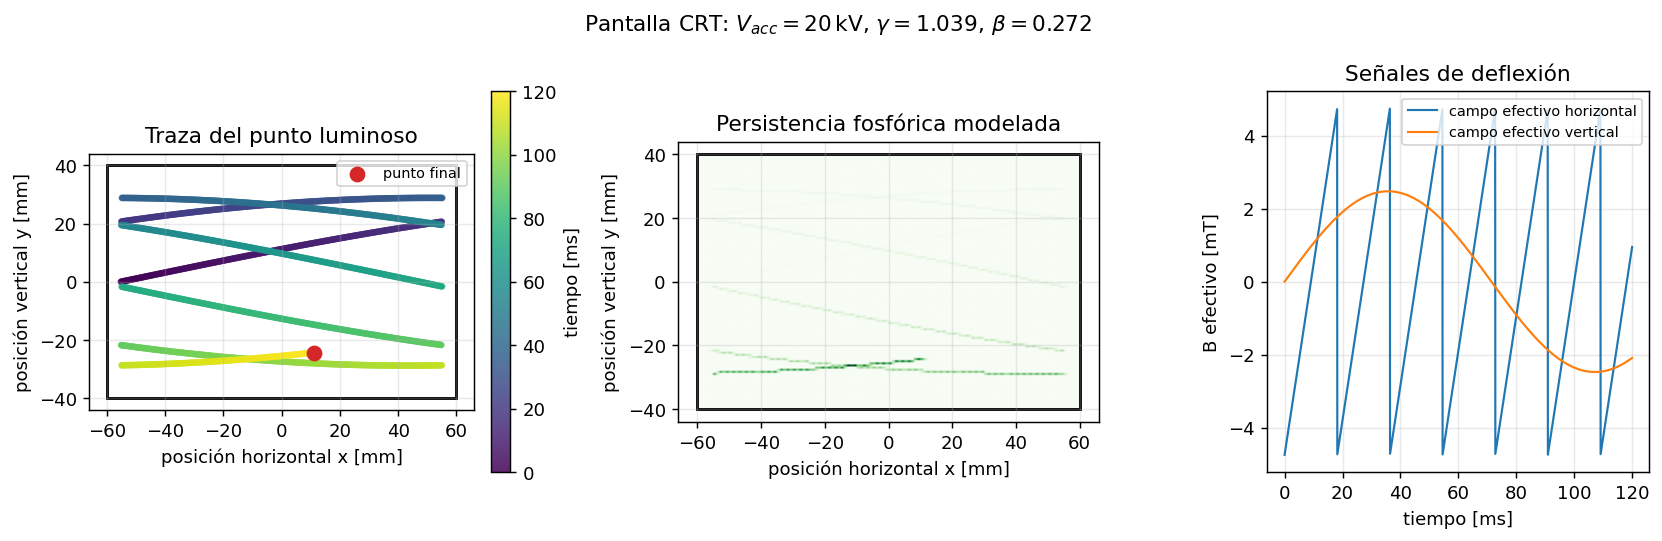

In [ ]:
V_acc = 20e3  # V
L_b = 0.04  # m
L_d = 0.12  # m
screen_width = 0.12  # m
screen_height = 0.08  # m
scan_frequency = 55.0  # Hz
vertical_frequency = 7.0  # Hz
duration = 0.12  # s
samples = 1800
t_screen = np.linspace(0.0, duration, samples)

gamma_crt = float(gamma_from_kinetic_energy(V_acc))
beta_crt = float(beta_from_gamma(gamma_crt))
v_crt = beta_crt * c
deflection_sensitivity = e_abs / (gamma_crt * m_e * v_crt) * (L_b*L_d + 0.5*L_b**2)

x_target = 0.46 * screen_width
y_target = 0.36 * screen_height
scan_phase = (scan_frequency * t_screen) % 1.0
x_signal = 2.0 * scan_phase - 1.0
y_signal = np.sin(2*np.pi*vertical_frequency*t_screen)

B_horizontal = x_target * x_signal / deflection_sensitivity
B_vertical = y_target * y_signal / deflection_sensitivity
x_screen = crt_deflection(B_horizontal, K_eV=V_acc, L_b=L_b, L_d=L_d)
y_screen = crt_deflection(B_vertical, K_eV=V_acc, L_b=L_b, L_d=L_d)

tau_phosphor = 0.030  # s
weights = np.exp(-(t_screen[-1] - t_screen) / tau_phosphor)
heatmap, x_edges, y_edges = np.histogram2d(
    x_screen,
    y_screen,
    bins=120,
    range=[[-screen_width/2, screen_width/2], [-screen_height/2, screen_height/2]],
    weights=weights,
)

fig, axs = plt.subplots(1, 3, figsize=(13.0, 4.2), gridspec_kw={"width_ratios": [1.1, 1.1, 1.0]})
for ax in axs[:2]:
    boundary = Rectangle((-screen_width/2*1e3, -screen_height/2*1e3), screen_width*1e3, screen_height*1e3,
                         fill=False, lw=1.6, edgecolor="black")
    ax.add_patch(boundary)
    ax.set_aspect("equal")
    ax.set_xlim(-screen_width*0.55*1e3, screen_width*0.55*1e3)
    ax.set_ylim(-screen_height*0.55*1e3, screen_height*0.55*1e3)
    ax.set_xlabel("posición horizontal x [mm]")
    ax.set_ylabel("posición vertical y [mm]")

trace = axs[0].scatter(x_screen*1e3, y_screen*1e3, c=t_screen*1e3, s=7, cmap="viridis", alpha=0.85)
axs[0].scatter([x_screen[-1]*1e3], [y_screen[-1]*1e3], s=60, color="tab:red", label="punto final")
axs[0].set_title("Traza del punto luminoso")
axs[0].legend(loc="upper right", fontsize=8)
cbar = fig.colorbar(trace, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_label("tiempo [ms]")

extent = [x_edges[0]*1e3, x_edges[-1]*1e3, y_edges[0]*1e3, y_edges[-1]*1e3]
axs[1].imshow(heatmap.T, origin="lower", extent=extent, cmap="Greens", aspect="equal")
axs[1].set_title("Persistencia fosfórica modelada")

axs[2].plot(t_screen*1e3, B_horizontal*1e3, lw=1.2, label="campo efectivo horizontal")
axs[2].plot(t_screen*1e3, B_vertical*1e3, lw=1.2, label="campo efectivo vertical")
axs[2].set_xlabel("tiempo [ms]")
axs[2].set_ylabel("B efectivo [mT]")
axs[2].set_title("Señales de deflexión")
axs[2].legend(fontsize=8)
fig.suptitle(fr"Pantalla CRT: $V_{{acc}}={V_acc/1e3:.0f}\,\mathrm{{kV}}$, $\gamma={gamma_crt:.3f}$, $\beta={beta_crt:.3f}$")
fig.tight_layout()
savefig("crt_screen_time_evolution.png")
plt.show()

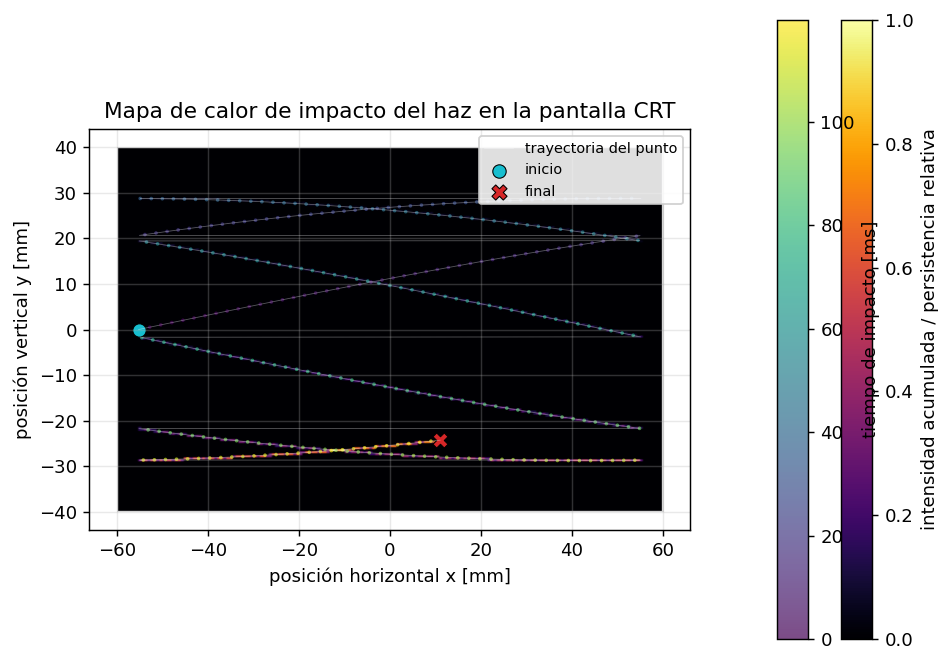

In [ ]:
heatmap_dwell, x_edges_dwell, y_edges_dwell = np.histogram2d(
    x_screen,
    y_screen,
    bins=180,
    range=[[-screen_width/2, screen_width/2], [-screen_height/2, screen_height/2]],
    weights=weights,
)
heatmap_dwell = heatmap_dwell / heatmap_dwell.max()
extent_dwell = [x_edges_dwell[0]*1e3, x_edges_dwell[-1]*1e3, y_edges_dwell[0]*1e3, y_edges_dwell[-1]*1e3]

fig, ax = plt.subplots(figsize=(7.4, 5.2))
image = ax.imshow(
    heatmap_dwell.T,
    origin="lower",
    extent=extent_dwell,
    cmap="inferno",
    aspect="equal",
    vmin=0.0,
    vmax=1.0,
)
trajectory = ax.scatter(
    x_screen[::6]*1e3,
    y_screen[::6]*1e3,
    c=t_screen[::6]*1e3,
    s=4,
    cmap="cyan_yellow_red" if "cyan_yellow_red" in plt.colormaps() else "viridis",
    alpha=0.70,
    linewidths=0,
)
ax.plot(x_screen*1e3, y_screen*1e3, color="white", lw=0.45, alpha=0.35, label="trayectoria del punto")
ax.scatter(x_screen[0]*1e3, y_screen[0]*1e3, s=55, marker="o", color="tab:cyan", edgecolor="black", linewidth=0.6, label="inicio")
ax.scatter(x_screen[-1]*1e3, y_screen[-1]*1e3, s=70, marker="X", color="tab:red", edgecolor="black", linewidth=0.6, label="final")
boundary = Rectangle((-screen_width/2*1e3, -screen_height/2*1e3), screen_width*1e3, screen_height*1e3, fill=False, lw=1.3, edgecolor="white", alpha=0.85)
ax.add_patch(boundary)
ax.set_xlabel("posición horizontal x [mm]")
ax.set_ylabel("posición vertical y [mm]")
ax.set_title("Mapa de calor de impacto del haz en la pantalla CRT")
ax.set_xlim(-screen_width*0.55*1e3, screen_width*0.55*1e3)
ax.set_ylim(-screen_height*0.55*1e3, screen_height*0.55*1e3)
ax.legend(loc="upper right", fontsize=8, framealpha=0.88)
cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("intensidad acumulada / persistencia relativa")
time_cbar = fig.colorbar(trajectory, ax=ax, fraction=0.046, pad=0.12)
time_cbar.set_label("tiempo de impacto [ms]")
fig.tight_layout()
savefig("crt_screen_heatmap.png")
plt.show()

**Interpretación del mapa de calor.** El mapa representa brillo acumulado del fósforo por impactos sucesivos del haz, ponderado con decaimiento exponencial de persistencia. Las zonas más brillantes indican posiciones donde el punto pasó más veces o más recientemente. No es un mapa de intensidad de radiación electromagnética: sigue siendo una visualización de deflexión por fuerza de Lorentz y del tiempo de permanencia del impacto sobre la pantalla CRT.

**Interpretación.** La posición del punto cambia porque el campo transversal modifica la dirección del haz por fuerza de Lorentz durante el tramo $L_b$ y esa pequeña inclinación se amplifica durante la deriva $L_d$. El barrido horizontal desplaza el punto de izquierda a derecha, mientras la señal vertical sinusoidal sube y baja la traza; la persistencia del fósforo deja visible una curva acumulada en lugar de un único punto instantáneo. Esta es una analogía de CRT porque muestra dónde impactan los electrones en una pantalla material. No es una fuente sincrotrón: no se grafica potencia radiada, espectro ni beaming relativista, sino deflexión geométrica de un haz de baja energía relativa.

## Conclusiones

1. En $20\,\mathrm{keV}$, típico de CRT, $\gamma=1.039$ y $\beta=0.272$: el patrón sigue siendo ancho y la escala de armónicos es $m_c\sim1.12$.

2. En $100\,\mathrm{keV}$, $\gamma=1.196$ y $\beta=0.548$: hay correcciones relativistas visibles, pero todavía no hay un cono estrecho de sincrotrón.

3. En $1\,\mathrm{MeV}$, $\gamma=2.957$ y $\beta=0.941$: el FWHM cae a una escala del orden de $2/\gamma$ y el patrón deja de parecer dipolar. Este es el umbral práctico de transición angular dentro de la lista estudiada.

4. En $100\,\mathrm{MeV}$ y $1\,\mathrm{GeV}$, $\gamma\gg1$: el lóbulo se comprime en un cono estrecho y $m_c\sim\gamma^3$ crece hasta órdenes muy altos. Ese es el régimen sincrotrón relativista claro.

5. La respuesta al problema es cuantitativa: la transición no ocurre por curvar cualquier haz, sino por alcanzar $\gamma$ suficientemente grande. El CRT es una buena analogía de deflexión de electrones, pero no una fuente sincrotrón fuerte ni espectralmente rica.

## Cobertura de la rúbrica

| Criterio | Evidencia en el notebook |
|---|---|
| Planteamiento del problema (15%) | Título, pregunta central y objetivos A--E. |
| Teoría (25%) | Cinemática relativista, fórmula angular, tiempo retardado, escala sincrotrón. |
| Solución computacional (40%) | Tablas, superficies 3D, mapas, FWHM, órbitas, tiempo retardado, FFT proxy y CRT. |
| Análisis y aplicaciones (10%) | Interpretaciones después de cada bloque y comparación CRT/sincrotrón. |
| Referencias (10%) | Schwinger/Milton caps. 34, 35 y 38 - Jacson cap. 14|

# Referencias 
[1] Schwinger, J., DeRaad, L. L., Jr., Milton, K. A., & Tsai, W.-Y. (1998). Classical electrodynamics. Perseus Books.
[2] J. D. Jackson, Classical Electrodynamics, 3rd ed., Wiley, 1999.
